In [1]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt

conn = psycopg2.connect(
    host="localhost",
    port=5432,
    database="shopeeth",
    user="postgres",
    password="win172001"
)

df = pd.read_sql("""
    SELECT 
        TO_DATE(year_month, 'YYYY-MM') as ds,
        SUM(total_amount) as y
    FROM raw_orders
    GROUP BY year_month
    ORDER BY year_month
""", conn)

conn.close()

df['ds'] = pd.to_datetime(df['ds'])
print(df.tail(10))

           ds             y
38 2025-03-01  1.037260e+08
39 2025-04-01  1.342307e+08
40 2025-05-01  1.290890e+08
41 2025-06-01  1.606667e+08
42 2025-07-01  1.533147e+08
43 2025-08-01  1.941043e+08
44 2025-09-01  2.531696e+08
45 2025-10-01  2.751734e+08
46 2025-11-01  3.371988e+08
47 2025-12-01  5.270529e+08


C:\Users\User\AppData\Local\Temp\ipykernel_23728\699241288.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt

# create numeric month index for modeling
df['month_index'] = range(len(df))
df['month'] = df['ds'].dt.month  # captures seasonality (1-12)

# features: month index (trend) + month number (seasonality)
X = df[['month_index', 'month']]
y = df['y']

# train model on all data
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

print("Model trained successfully!")
print(f"R2 Score on training data: {model.score(X_poly, y):.4f}")

Model trained successfully!
R2 Score on training data: 0.9057


In [3]:
# create 2026 monthly dates
future_dates = pd.date_range(start='2026-01-01', periods=12, freq='MS')
future_df = pd.DataFrame({
    'ds': future_dates,
    'month_index': range(len(df), len(df) + 12),
    'month': future_dates.month
})

# predict
X_future = future_df[['month_index', 'month']]
X_future_poly = poly.transform(X_future)
future_df['predicted_revenue'] = model.predict(X_future_poly)

# print results
print("\n=== 2026 Monthly Revenue Forecast ===")
print(f"{'Month':<15} {'Predicted Revenue (THB)':>25}")
print("-" * 40)
for _, row in future_df.iterrows():
    print(f"{str(row['ds'].date()):<15} {row['predicted_revenue']:>25,.0f}")


=== 2026 Monthly Revenue Forecast ===
Month             Predicted Revenue (THB)
----------------------------------------
2026-01-01                    199,680,056
2026-02-01                    216,619,235
2026-03-01                    237,168,885
2026-04-01                    261,329,007
2026-05-01                    289,099,601
2026-06-01                    320,480,667
2026-07-01                    355,472,204
2026-08-01                    394,074,214
2026-09-01                    436,286,695
2026-10-01                    482,109,649
2026-11-01                    531,543,074
2026-12-01                    584,586,971


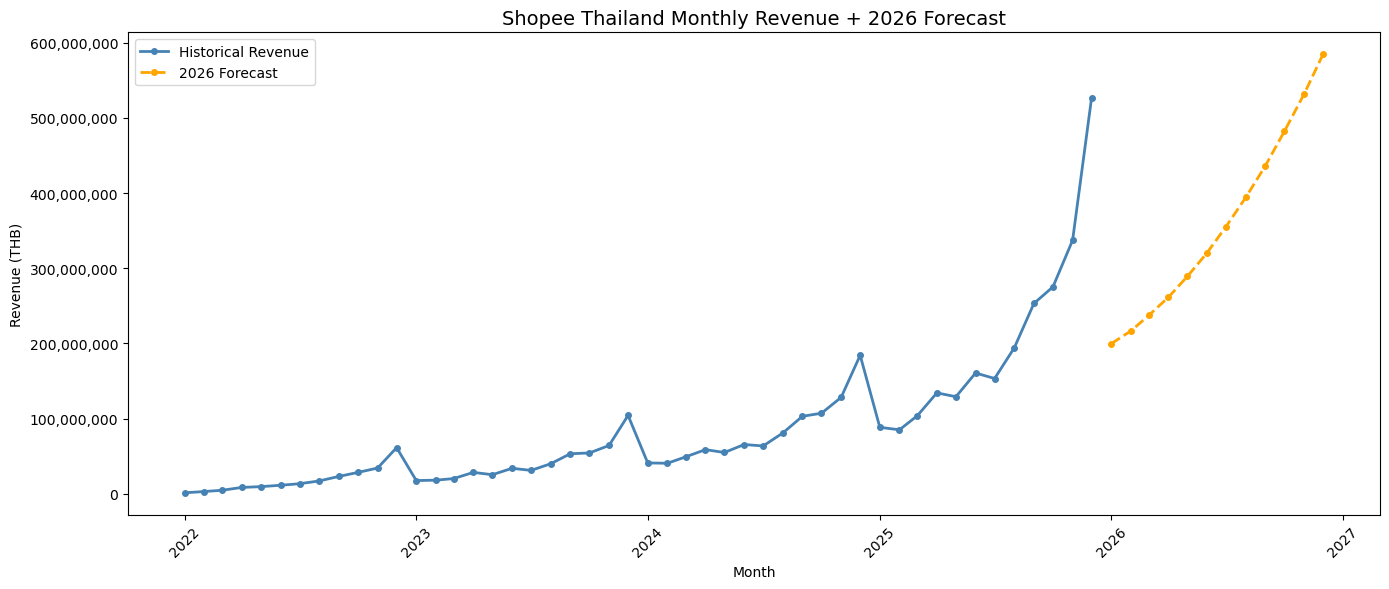

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))

# plot historical data
ax.plot(df['ds'], df['y'], 
        label='Historical Revenue', 
        color='steelblue', 
        linewidth=2,
        marker='o',
        markersize=4)

# plot forecast
ax.plot(future_df['ds'], future_df['predicted_revenue'],
        label='2026 Forecast',
        color='orange',
        linewidth=2,
        linestyle='--',
        marker='o',
        markersize=4)

# formatting
ax.set_title('Shopee Thailand Monthly Revenue + 2026 Forecast', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (THB)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
# re-add columns
df['month_index'] = range(len(df))
df['month'] = df['ds'].dt.month
df['is_december'] = (df['ds'].dt.month == 12).astype(int)

# retrain with december feature
X2 = df[['month_index', 'month', 'is_december']]
poly2 = PolynomialFeatures(degree=2)
X2_poly = poly2.fit_transform(X2)

model2 = LinearRegression()
model2.fit(X2_poly, y)

print(f"R2 Score with seasonality: {model2.score(X2_poly, y):.4f}")

# forecast 2026 with december feature
future_df['is_december'] = (future_df['ds'].dt.month == 12).astype(int)
X_future2 = future_df[['month_index', 'month', 'is_december']]
X_future2_poly = poly2.transform(X_future2)
future_df['predicted_revenue_v2'] = model2.predict(X_future2_poly)

# print results
print("\n=== 2026 Forecast with December Spike ===")
print(f"{'Month':<15} {'Predicted Revenue (THB)':>25}")
print("-" * 40)
for _, row in future_df.iterrows():
    print(f"{str(row['ds'].date()):<15} {row['predicted_revenue_v2']:>25,.0f}")

R2 Score with seasonality: 0.9452

=== 2026 Forecast with December Spike ===
Month             Predicted Revenue (THB)
----------------------------------------
2026-01-01                    210,419,767
2026-02-01                    227,885,361
2026-03-01                    247,295,503
2026-04-01                    268,650,193
2026-05-01                    291,949,430
2026-06-01                    317,193,216
2026-07-01                    344,381,550
2026-08-01                    373,514,432
2026-09-01                    404,591,861
2026-10-01                    437,613,839
2026-11-01                    472,580,365
2026-12-01                    712,374,741


In [6]:
# separate features for 11.11 and 12.12
df['month_index'] = range(len(df))
df['month'] = df['ds'].dt.month
df['is_november'] = (df['ds'].dt.month == 11).astype(int)
df['is_december'] = (df['ds'].dt.month == 12).astype(int)

y = df['y']
X4 = df[['month_index', 'month', 'is_november', 'is_december']]

poly4 = PolynomialFeatures(degree=2)
X4_poly = poly4.fit_transform(X4)

model4 = LinearRegression()
model4.fit(X4_poly, y)

print(f"R2 Score: {model4.score(X4_poly, y):.4f}")

# forecast 2026
future_df['is_november'] = (future_df['ds'].dt.month == 11).astype(int)
future_df['is_december'] = (future_df['ds'].dt.month == 12).astype(int)

X_future4 = future_df[['month_index', 'month', 'is_november', 'is_december']]
X_future4_poly = poly4.transform(X_future4)
future_df['predicted_revenue_v4'] = model4.predict(X_future4_poly)

print("\n=== 2026 Forecast (November & December Separated) ===")
print(f"{'Month':<15} {'Predicted Revenue (THB)':>25}")
print("-" * 40)
for _, row in future_df.iterrows():
    print(f"{str(row['ds'].date()):<15} {row['predicted_revenue_v4']:>25,.0f}")

R2 Score: 0.9481

=== 2026 Forecast (November & December Separated) ===
Month             Predicted Revenue (THB)
----------------------------------------
2026-01-01                    216,013,747
2026-02-01                    232,116,967
2026-03-01                    249,913,591
2026-04-01                    269,403,621
2026-05-01                    290,587,056
2026-06-01                    313,463,896
2026-07-01                    338,034,141
2026-08-01                    364,297,791
2026-09-01                    392,254,846
2026-10-01                    421,905,306
2026-11-01                    508,084,553
2026-12-01                    712,374,741


In [7]:
# check historical november vs december
campaign_months = df[df['ds'].dt.month.isin([11, 12])][['ds', 'y', 'is_november', 'is_december']]
print(campaign_months.to_string())

           ds             y  is_november  is_december
10 2022-11-01  3.423453e+07            1            0
11 2022-12-01  6.135831e+07            0            1
22 2023-11-01  6.426791e+07            1            0
23 2023-12-01  1.042315e+08            0            1
34 2024-11-01  1.282316e+08            1            0
35 2024-12-01  1.842274e+08            0            1
46 2025-11-01  3.371988e+08            1            0
47 2025-12-01  5.270529e+08            0            1


In [12]:
total_2026 = future_df['predicted_revenue_v4'].sum()
best_month = future_df.loc[future_df['predicted_revenue_v4'].idxmax(), 'ds']
best_revenue = future_df['predicted_revenue_v4'].max()

print("=== 2026 Revenue Forecast Summary ===")
print(f"Total predicted 2026 revenue : {total_2026:,.0f} THB")
print(f"Total predicted 2026 revenue : {total_2026/1e9:.2f} Billion THB")
print(f"Peak month                   : {best_month.strftime('%B %Y')}")
print(f"Peak month revenue           : {best_revenue:,.0f} THB")
print(f"Average monthly revenue      : {total_2026/12:,.0f} THB")

=== 2026 Revenue Forecast Summary ===
Total predicted 2026 revenue : 4,308,450,257 THB
Total predicted 2026 revenue : 4.31 Billion THB
Peak month                   : December 2026
Peak month revenue           : 712,374,741 THB
Average monthly revenue      : 359,037,521 THB


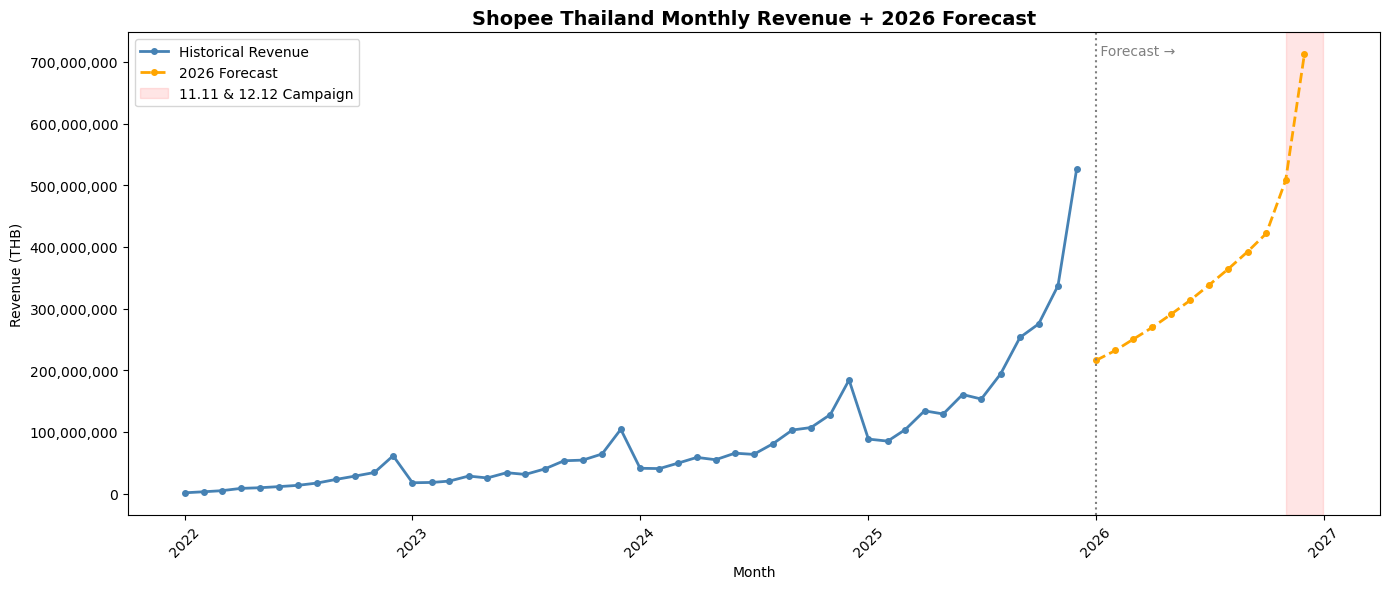

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

# historical
ax.plot(df['ds'], df['y'], 
        label='Historical Revenue', 
        color='steelblue', 
        linewidth=2,
        marker='o',
        markersize=4)

# forecast
ax.plot(future_df['ds'], future_df['predicted_revenue_v4'],
        label='2026 Forecast',
        color='orange',
        linewidth=2,
        linestyle='--',
        marker='o',
        markersize=4)

# highlight campaign months
ax.axvspan(pd.Timestamp('2026-11-01'), pd.Timestamp('2026-12-31'), 
           alpha=0.1, color='red', label='11.11 & 12.12 Campaign')

# vertical line separating historical and forecast
ax.axvline(x=pd.Timestamp('2026-01-01'), 
           color='gray', linestyle=':', linewidth=1.5)
ax.text(pd.Timestamp('2026-01-01'), ax.get_ylim()[1]*0.95, 
        ' Forecast →', color='gray', fontsize=10)

# formatting
ax.set_title('Shopee Thailand Monthly Revenue + 2026 Forecast', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (THB)')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()